<div style="float: block; text-align: center; line-height: 1.7em">
    <span style="font-size: 2em; font-weight: bold"> Fatigue-Sleepiness in Irregular Workloads for Pilots </span><br>
    <span style="font-size: 1.5em; font-weight: bold"> Statistical Modelling - Perception of Severe Fatigue </span><br>
</div>

----

---

# 1. Loading Libraries and Packages

In [1]:
import os                                            # system library
import pandas as pd                                  # library to handle databases
import numpy as np                                   # library to handle arrays and matrices
import matplotlib.pyplot as plt                      # graphical package
import seaborn as sns                                # beautification graphical package
from IPython.display import display, HTML

os.environ['R_HOME'] = "C:/PROGRA~1/R/R-44~1.2"      # Necessary to configure R_HOME path
from pymer4.models import Lmer                       # Package for statistical modelling
from pymer4.io import save_model                     # To save the model

import rpy2.robjects as ro                           # Forcing to UTF-8 locale
ro.r('Sys.setlocale("LC_ALL", "English_United States.UTF-8")')

from sklearn.metrics import roc_auc_score, roc_curve, classification_report, accuracy_score, confusion_matrix, auc
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

----

# 2. Reading Processed Data

In [2]:
file = os.path.join('data','03.fat_wrk_mdl_train.csv')
try:
    df = pd.read_csv(file)
    print('-----------------------------------------------')
    print(f"\033[93mSuccess Data file read!\033[0m")
    print('-----------------------------------------------')
    # display(df.head(3))
except Exception as e:
    print('-----------------------------------------------')
    print(f"\033[91mAn error occurred:\033[0m {e}")
    print('-----------------------------------------------')

-----------------------------------------------
Success Data file read!
-----------------------------------------------


----

# 3. Verifying for Null rows

In [3]:
df['Sleep_quality'] = pd.to_numeric(df['Sleep_quality'], errors = 'coerce')
wsm = df.isna().sum()
display(pd.DataFrame(wsm).T)

,Id,TPFS_fat,duty_moment,DMod_fat,PDMod_fat,Sleep_quality,time_awake,duty_length,age,Age,spsd
0,0,0,0,0,0,24,4,4,0,0,0


* As we can see above for covariates time_awake and sleep duration there are some null rows, so these rows containing null values will be taken away.

In [4]:
df = df.dropna()

wsm = df.isna().sum()
display(pd.DataFrame(wsm).T)

,Id,TPFS_fat,duty_moment,DMod_fat,PDMod_fat,Sleep_quality,time_awake,duty_length,age,Age,spsd
0,0,0,0,0,0,0,0,0,0,0,0


* Now as we can see, there is no longer null rows!

---

# 4. Scalling some covariates

To avoid scalling bias in the model, we will rescalling some continuous covariates.

In [5]:
df[['Sleep_quality','time_awake','duty_length']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_quality,1026.0,7.321637,1.696441,2.000000,6.0,8.000000,9.000000,10.000000
time_awake,1026.0,3.872498,3.510890,0.250000,1.5,2.375000,5.016667,17.400000
duty_length,1026.0,7.291131,2.328124,1.683333,6.0,7.466667,8.850000,11.583333


Above is shown some descriptive statistics of the ordinal and continuous covariates, based on the covariate statistics we propose the max-min standardization.

In [6]:
df['Sleep_quality'] = df['Sleep_quality']/(df['Sleep_quality'].max()-df['Sleep_quality'].min())
df['time_awake'] = df['time_awake']/(df['time_awake'].max()-df['time_awake'].min())
df['duty_length'] = df['duty_length']/(df['duty_length'].max()-df['duty_length'].min())

---

# 5. Preliminary Regression Analysis

As we are dealing with repeated measure or a panel like data, a **mixed logistic model controlled by participant** is a suitabel model, given by:

<p style="text-align: center;"> $g(x_{ij},\beta_{0i},\beta_1, \beta_s) = \beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s$ $\:\:\:$  (logistic model) </p>
<p style="text-align: center;"> $\beta_{0i} = \beta_0 + \alpha_i$ $\:\:\:$ (random intercept) </p>

where $\alpha_i \sim N(0,\sigma_\alpha^2)$ .

with $\alpha_i$ representing the random intercept due to participant variability and $\beta_0$ the intercept or baseline.

The logistic link function os given by:

<p style="text-align: center;"> $$g(x_{ij},\beta_{0i},\beta_1, \beta_s) = ln\left[\frac{\pi(x_{ij},\beta_{0i},\beta_1, \beta_s)}{1-\pi(x_{ij},\beta_{0i},\beta_1, \beta_s)}\right]$$ </p>

with, 

<p style="text-align: center;"> $$\pi(x_{ij},\beta_{0i},\beta_1, \beta_s) = \frac{e^{\beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s}}{1+e^{\beta_{0i}+\beta_{1i}x_1 + x_{ij}^T\beta_s}}$$</p>


## 5.1. Function to codify the covariates in pymer standards

In [7]:
def get_formula(covariates, target, prnt = False):
    formula = f'{target}~'
    for cvt in covariates:
        formula += cvt+'+'
    formula = formula[:-1]
    if prnt:
        print(f'formula:\n{formula}')
    return formula

## 5.2. First Iteration

In [8]:
covariates = ['TPFS_fat','duty_moment','Sleep_quality','age', 'DMod_fat', 'PDMod_fat', 'time_awake', 'duty_length']
#covariates = ['duty_moment','DMod_fat','Sleep_quality','time_awake','duty_length','age']

formula = get_formula(covariates, 'spsd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')


model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: spsd~TPFS_fat+duty_moment+Sleep_quality+age+DMod_fat+PDMod_fat+time_awake+duty_length+(1|Id)
----------------------------------------------------------------------------------------------------------
Model failed to converge with max|grad| = 0.0418494 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: spsd~TPFS_fat+duty_moment+Sleep_quality+age+DMod_fat+PDMod_fat+time_awake+duty_length+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -179.312 	 AIC: 382.624

Random effects:

           Name    Var    Std
Id  (Intercept)  0.923  0.961

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-2.064,-3.961,-0.168,0.968,0.127,0.019,0.846,0.113,0.019,0.458,-2.133,0.033,*
TPFS_fatNI,0.596,-0.241,1.432,0.427,1.814,0.786,4.187,0.645,0.440,0.807,1.396,0.163,
duty_momentmiddle,-2.391,-3.170,-1.611,0.398,0.092,0.042,0.200,0.084,0.040,0.166,-6.012,0.000,***
duty_momentstart,-5.155,-7.202,-3.107,1.045,0.006,0.001,0.045,0.006,0.001,0.043,-4.935,0.000,***
Sleep_quality,-4.251,-5.875,-2.627,0.829,0.014,0.003,0.072,0.014,0.003,0.067,-5.130,0.000,***
agemiddle,1.184,0.277,2.091,0.463,3.268,1.320,8.092,0.766,0.569,0.890,2.560,0.010,*
DMod_fatearly-start,-0.332,-1.414,0.751,0.552,0.718,0.243,2.119,0.418,0.196,0.679,-0.600,0.548,
DMod_fatni,0.896,0.139,1.652,0.386,2.449,1.150,5.218,0.710,0.535,0.839,2.321,0.020,*
PDMod_fates,-1.136,-2.962,0.691,0.932,0.321,0.052,1.995,0.243,0.049,0.666,-1.219,0.223,
time_awake,3.274,1.615,4.932,0.846,26.413,5.030,138.699,0.964,0.834,0.993,3.869,0.000,***


Above is presented the output of pymer library for the first iteration. As we can see, some covariates suggested in exploratory data analysis have no statistically significant effect at the level of 5% (p-value < 0.05), as:

* TPFS_ftNI (Time the participant filled the scales Night)

* DMod_fatearly-start (Duty modality early-start)

* PDMod_fates (Previous duty modality early-start)

# 5.3. Second Iteration

### 5.3.1. Transforming Variable Duty Modality

In [9]:
df['DMod_fat_2'] = df['DMod_fat'].apply(lambda x: 'base' if x == 'early-start' else x)

In [10]:
df['duty_moment2'] = df['duty_moment'].apply(lambda x: 'a_start' if x == 'start' else x)

### 5.3.2. Logistic Model

In [11]:
covariates = ['duty_moment2','Sleep_quality','age', 'DMod_fat_2', 'time_awake', 'duty_length']

formula = get_formula(covariates, 'spsd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')


model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: spsd~duty_moment2+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)
----------------------------------------------------------------------------------------------------------
Model failed to converge with max|grad| = 0.130069 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: spsd~duty_moment2+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -181.736 	 AIC: 381.472

Random effects:

           Name    Var    Std
Id  (Intercept)  0.912  0.955

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-7.925,-10.583,-5.266,1.356,0.000,0.000,0.005,0.000,0.000,0.005,-5.842,0.000,***
duty_moment2end,5.197,3.182,7.213,1.028,180.817,24.089,1357.217,0.994,0.960,0.999,5.054,0.000,***
duty_moment2middle,2.765,0.700,4.829,1.054,15.872,2.013,125.138,0.941,0.668,0.992,2.624,0.009,**
Sleep_quality,-4.007,-5.573,-2.440,0.799,0.018,0.004,0.087,0.018,0.004,0.080,-5.012,0.000,***
agemiddle,1.191,0.291,2.092,0.459,3.291,1.337,8.097,0.767,0.572,0.890,2.593,0.010,**
DMod_fat_2ni,1.243,0.582,1.903,0.337,3.464,1.790,6.706,0.776,0.642,0.870,3.687,0.000,***
time_awake,3.831,2.364,5.298,0.749,46.118,10.634,200.009,0.979,0.914,0.995,5.118,0.000,***
duty_length,3.495,1.882,5.108,0.823,32.954,6.570,165.295,0.971,0.868,0.994,4.248,0.000,***


>- Now as we can see, all the covariates present statistically significant effects at the p-level of 0.05 or 5%.
>
>- However, looking at the coefficients we see things like OR exploding and too wide intervals, like in duty moment and time awake before duty, some problems could be the covariate perfectly predicting the target or response (leakage), multicolinearity, or rarity of the target class, too much targets in few categories.
>
>- **For Duty Moment, in section 4 in the Exploratory Analysis notebook in figure *Severe Fatigue in Working Days*, we can see that the class *start* has probability of occurrence of the target almost zero, so this might be pushing the coefficient to high values, jeopardizing the analysis. So, it is advised to recategorize this feature.**
>
>- The coefficients for duty lenght and time awake must be reescaled to the original scale before min-max transformation.

## 5.4. Third Iteration

In [12]:
df['duty_moment3'] = df['duty_moment'].apply(lambda x: 'a_start' if x in ['start','middle'] else x)

In [13]:
covariates = ['duty_moment3','Sleep_quality','age', 'DMod_fat_2', 'time_awake', 'duty_length']

formula = get_formula(covariates, 'spsd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')

model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: spsd~duty_moment3+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)
----------------------------------------------------------------------------------------------------------
Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: spsd~duty_moment3+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -188.114 	 AIC: 392.229

Random effects:

           Name    Var    Std
Id  (Intercept)  0.946  0.973

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-6.070,-7.963,-4.178,0.966,0.002,0.000,0.015,0.002,0.000,0.015,-6.287,0.000,***
duty_moment3end,3.235,2.491,3.978,0.379,25.396,12.079,53.396,0.962,0.924,0.982,8.531,0.000,***
Sleep_quality,-3.922,-5.466,-2.379,0.788,0.020,0.004,0.093,0.019,0.004,0.085,-4.980,0.000,***
agemiddle,1.165,0.260,2.070,0.462,3.207,1.298,7.926,0.762,0.565,0.888,2.524,0.012,*
DMod_fat_2ni,1.223,0.565,1.881,0.336,3.397,1.759,6.561,0.773,0.638,0.868,3.641,0.000,***
time_awake,3.776,2.328,5.224,0.739,43.656,10.261,185.744,0.978,0.911,0.995,5.111,0.000,***
duty_length,3.581,1.979,5.182,0.817,35.905,7.239,178.093,0.973,0.879,0.994,4.383,0.000,***


In [14]:
covariates = ['duty_moment3','Sleep_quality','age', 'DMod_fat_2', 'time_awake', 'duty_length']

formula = get_formula(covariates, 'spsd', prnt=False)
ff = formula + '+(1|Id)'

print('----------------------------------------------------------------------------------------------------------')
print(f'\033[91mFormula: {ff}\033[0m')
print('----------------------------------------------------------------------------------------------------------')

model_LME = Lmer(ff, data = df, family = 'binomial')
mdf = model_LME.fit()

mdf.head(100)

----------------------------------------------------------------------------------------------------------
Formula: spsd~duty_moment3+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)
----------------------------------------------------------------------------------------------------------
Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: spsd~duty_moment3+Sleep_quality+age+DMod_fat_2+time_awake+duty_length+(1|Id)

Family: binomial	 Inference: parametric

Number of observations: 1026	 Groups: {'Id': 44.0}

Log-likelihood: -188.114 	 AIC: 392.229

Random effects:

           Name    Var    Std
Id  (Intercept)  0.946  0.973

No random effect correlations specified

Fixed effects:



C:\Users\jlpsc\anaconda3\envs\pymer4_projects\lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-6.070,-7.963,-4.178,0.966,0.002,0.000,0.015,0.002,0.000,0.015,-6.287,0.000,***
duty_moment3end,3.235,2.491,3.978,0.379,25.396,12.079,53.396,0.962,0.924,0.982,8.531,0.000,***
Sleep_quality,-3.922,-5.466,-2.379,0.788,0.020,0.004,0.093,0.019,0.004,0.085,-4.980,0.000,***
agemiddle,1.165,0.260,2.070,0.462,3.207,1.298,7.926,0.762,0.565,0.888,2.524,0.012,*
DMod_fat_2ni,1.223,0.565,1.881,0.336,3.397,1.759,6.561,0.773,0.638,0.868,3.641,0.000,***
time_awake,3.776,2.328,5.224,0.739,43.656,10.261,185.744,0.978,0.911,0.995,5.111,0.000,***
duty_length,3.581,1.979,5.182,0.817,35.905,7.239,178.093,0.973,0.879,0.994,4.383,0.000,***


### 5.4.1. Rescaling Time Awake, Duty Length and Sleep Quality

In [15]:
df_coefs = mdf.copy()
 
df_coefs.loc['Sleep_quality','OR'] = np.exp(df_coefs.loc['Sleep_quality','Estimate']/4)   # Every two levels in scale
df_coefs.loc['Sleep_quality','OR_2.5_ci'] = np.exp(df_coefs.loc['Sleep_quality','2.5_ci']/4)
df_coefs.loc['Sleep_quality','OR_97.5_ci'] = np.exp(df_coefs.loc['Sleep_quality','97.5_ci']/4)

df_coefs.loc['time_awake','OR'] = np.exp(df_coefs.loc['time_awake','Estimate']/(17.15/10))    # Every 10 hours
df_coefs.loc['time_awake','OR_2.5_ci'] = np.exp(df_coefs.loc['time_awake','2.5_ci']/(17.15/10))
df_coefs.loc['time_awake','OR_97.5_ci'] = np.exp(df_coefs.loc['time_awake','97.5_ci']/(17.15/10))

df_coefs.loc['duty_length','OR'] = np.exp(df_coefs.loc['duty_length','Estimate']/(9.90/2))    # Every 8 hours
df_coefs.loc['duty_length','OR_2.5_ci'] = np.exp(df_coefs.loc['duty_length','2.5_ci']/(9.90/2))
df_coefs.loc['duty_length','OR_97.5_ci'] = np.exp(df_coefs.loc['duty_length','97.5_ci']/(9.90/2))

df_coefs.head(100)

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-6.070,-7.963,-4.178,0.966,0.002000,0.000000,0.015000,0.002,0.000,0.015,-6.287,0.000,***
duty_moment3end,3.235,2.491,3.978,0.379,25.396000,12.079000,53.396000,0.962,0.924,0.982,8.531,0.000,***
Sleep_quality,-3.922,-5.466,-2.379,0.788,0.375123,0.254998,0.551700,0.019,0.004,0.085,-4.980,0.000,***
agemiddle,1.165,0.260,2.070,0.462,3.207000,1.298000,7.926000,0.762,0.565,0.888,2.524,0.012,*
DMod_fat_2ni,1.223,0.565,1.881,0.336,3.397000,1.759000,6.561000,0.773,0.638,0.868,3.641,0.000,***
time_awake,3.776,2.328,5.224,0.739,9.040815,3.886210,21.032401,0.978,0.911,0.995,5.111,0.000,***
duty_length,3.581,1.979,5.182,0.817,2.061501,1.491523,2.848717,0.973,0.879,0.994,4.383,0.000,***


>- Now, after rescalling the continuous covariates (OR coeff only) and after applying the recategorization in duty moment, we can choose this model to further analysis.

---

# 6. Model Assessment

## 6.1. Overdispersion Ratio

The Overdispersion ratio for binomial model is given by:

$$ \phi = \frac{ \sum_{i=1}^{n} r_i^2}{df}$$

where $r_i^2$ is the squared sum of residuals and $df$ is the degrees of freedom of the model.

In [16]:
res = model_LME.residuals
pearson = np.sum((res)**2)
df_resid = model_LME.data.shape[0] - len(model_LME.fixef)
overdispersion_ratio = pearson / df_resid

print('-------------------------------')
print(f'\033[91m OD = {round(overdispersion_ratio, 3)}\033[0m')
print('-------------------------------')

-------------------------------
 OD = 0.331
-------------------------------


As we can see $OD<1$, meaning underdispersion, meaning that:

>- The model's predicted variance is slightly larger than the observed variance.
>
>- The random effects structure is appropriate.
>
>- The predictor explains a good amount of the variability of the model.
>
>- The random intercept variance is 0.946 with SD = 0.973, that looks acceptable. In overdispersion cases the random intercept variance is near zero or inflated.  

Overall, this check means that the model is not miss-specified, there is no evidence of overdispersion.

## 6.2. Performance Analysis

In [17]:
# Getting predictions from training set, evaluated by the model
df_res = pd.DataFrame({'y_that':list(model_LME.fits),'y':df.spsd})

### 6.2.1. Curve ROC and AUC

In [18]:
# Computing ROC curve

fpr, tpr, thresholds = roc_curve(df_res['y'], df_res['y_that']-min(df_res['y_that']))
roc_auc = auc(fpr, tpr)

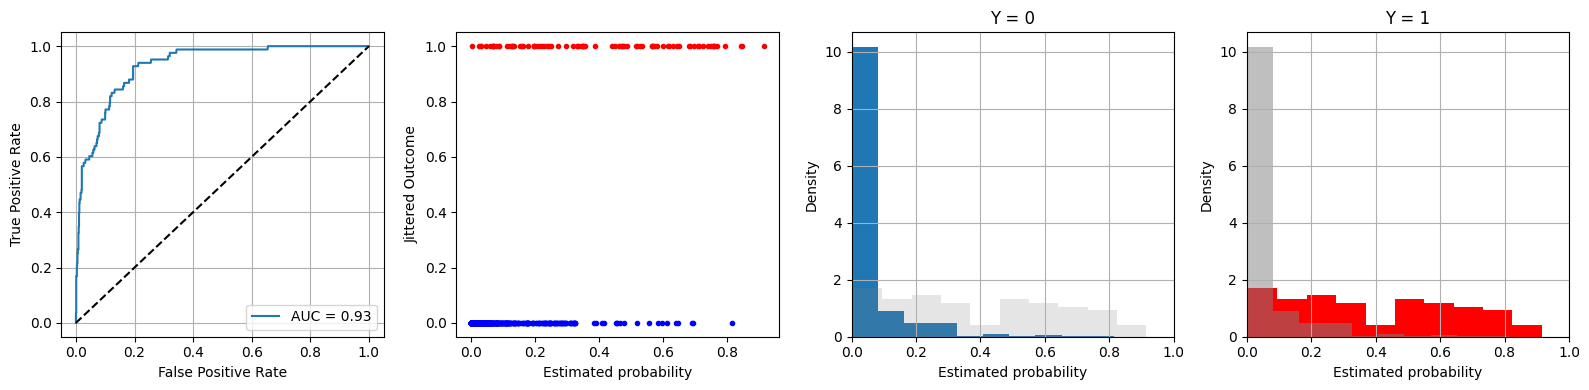

In [19]:
fig, ax = plt.subplots(1,4, figsize = (16,4))

ax[0].plot(fpr, tpr, label=f'AUC = {str(round(roc_auc, 2))}')
ax[0].plot([0,1], [0,1],'k--',)
ax[0].legend(loc='lower right')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].grid(True)

ax[1].plot(df_res.y_that[df_res.y == 0], df_res.y[df_res.y == 0],'.' ,color = 'blue')
ax[1].plot(df_res.y_that[df_res.y == 1], df_res.y[df_res.y == 1],'.',color = 'red')
ax[1].set_xlabel('Estimated probability')
ax[1].set_ylabel('Jittered Outcome')

ax[2].hist(df_res.y_that[df_res.y == 0], density = True)
ax[2].hist(df_res.y_that[df_res.y == 1], density = True, color = 'gray', alpha=0.2)
ax[2].set_xlabel('Estimated probability')
ax[2].set_ylabel('Density')
ax[2].set_title('Y = 0')
ax[2].set_xlim(0,1)
ax[2].grid(True)

ax[3].hist(df_res.y_that[df_res.y == 1], density = True, color = 'red')
ax[3].hist(df_res.y_that[df_res.y == 0], density = True, color = 'gray', alpha=0.5)
ax[3].set_xlabel('Estimated probability')
ax[3].set_ylabel('Density')
ax[3].set_title('Y = 1')
ax[3].set_xlim(0,1)
ax[3].grid(True)

plt.tight_layout()
plt.show()
fig.savefig('figures/05.performance_model.png')

Figures above show some KPIs for model assesment. Therefore,

> * The leftmost figure shows the ROC curve and the AUC metric. As we can see, the value of AUC is 0.93 showing that the model can be considered an outstanding discriminator (Following the scale presented in Hosmer and Lemeshow (2003)).
>
> * The jittered outcome figure presents how the predicted positives and negatives distributes along the estimated probability domain, with the red points representing the indicator of perception of severe fatigue while the blue ones representing the opposite. As we can see as expected the blue points concentrates toward lower estimated probability and the red points is well distributed along the estimated probability domain.
>
> * The two figures at the right part of the pannel presents the density estimate for the model predictions of perception of no extreme condition (Y=0) and extreme conditions (Y=1) of perceived fatigue. We can see the same as interpreted for the jittered outcome.  

### 6.2.2. Curve Precision-Recall & AUC-PR

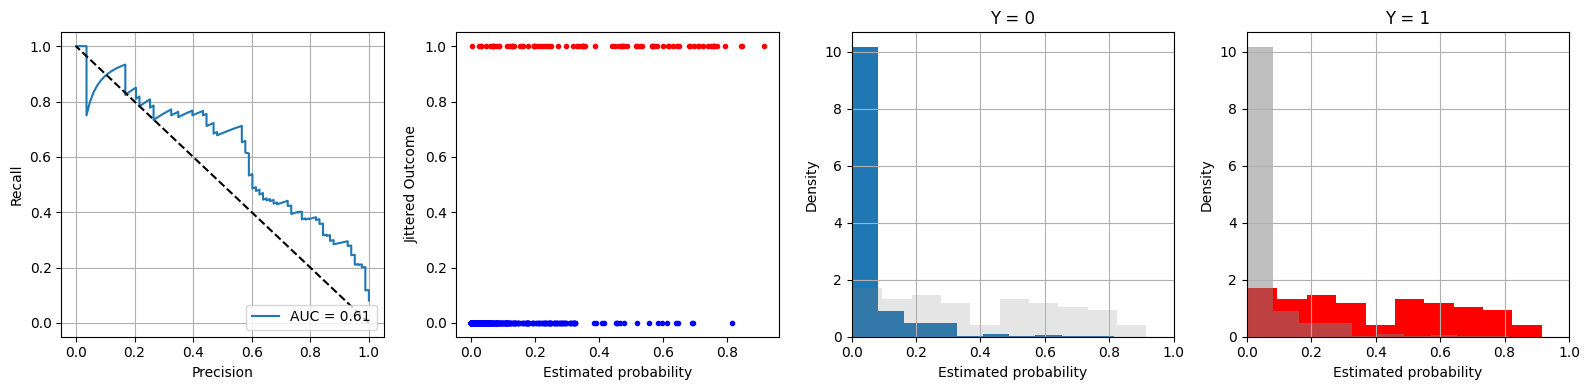

In [20]:
precision, recall, _ = precision_recall_curve(df_res['y'], df_res['y_that']-min(df_res['y_that']))
roc_auc_pr = auc(recall, precision)

fig, ax = plt.subplots(1,4, figsize = (16,4))

ax[0].plot(recall, precision, label=f'AUC = {str(round(roc_auc_pr, 2))}')
ax[0].plot([1,0], [0,1],'k--',)
ax[0].legend(loc='lower right')
ax[0].set_ylabel('Recall')
ax[0].set_xlabel('Precision')
ax[0].grid(True)

ax[1].plot(df_res.y_that[df_res.y == 0], df_res.y[df_res.y == 0],'.' ,color = 'blue')
ax[1].plot(df_res.y_that[df_res.y == 1], df_res.y[df_res.y == 1],'.',color = 'red')
ax[1].set_xlabel('Estimated probability')
ax[1].set_ylabel('Jittered Outcome')

ax[2].hist(df_res.y_that[df_res.y == 0], density = True)
ax[2].hist(df_res.y_that[df_res.y == 1], density = True, color = 'gray', alpha=0.2)
ax[2].set_xlabel('Estimated probability')
ax[2].set_ylabel('Density')
ax[2].set_title('Y = 0')
ax[2].set_xlim(0,1)
ax[2].grid(True)

ax[3].hist(df_res.y_that[df_res.y == 1], density = True, color = 'red')
ax[3].hist(df_res.y_that[df_res.y == 0], density = True, color = 'gray', alpha=0.5)
ax[3].set_xlabel('Estimated probability')
ax[3].set_ylabel('Density')
ax[3].set_title('Y = 1')
ax[3].set_xlim(0,1)
ax[3].grid(True)

plt.tight_layout()
plt.show()
fig.savefig('figures/05.performance_model_pr.png')

Figures above show another KPI to assess the model, the precision-recall curve and their corresponding AUC score.

>- The lefmost figure presents the precision-recall curve to assess the performance of the model concerning the precision and sensitivity. The AUC metrics is 0.61 meaning that our classificator for the minority class is not so outstanding when compared to AUC metrics obtained from the AUC ROC metrics pointed in previous sections.
>
>- Due to the limitations of the data, (low data quantity for a longitudinal study given the number of individuals), and the nature of the problem (without the intent to predict but with the intent to understanding factors influencing the perception of severe fatigue), we can take this metrics as reasonable and acceptable for this kind of study.

### 6.2.2. Confusion Matrix & Callibration

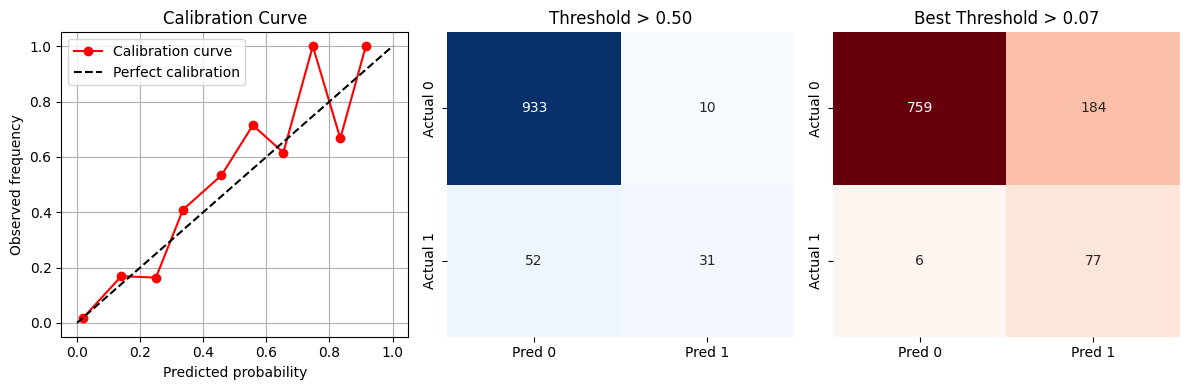

In [21]:
y_prob = df_res['y_that']
y_true = df_res['y']

y_pred_opt = (np.array(y_prob) >= 0.50).astype(int)
cm = confusion_matrix(y_true, y_pred_opt)
cm_prev = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])

# Youden J statistic
j_scores = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]
#print(f"Optimal threshold (Youden's J): {best_thresh:.3f}")

# Confusion matrix at optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_true, y_pred_opt)
#print("Confusion Matrix at Optimal Threshold:")
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
#print(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1']))

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))
ax[0].plot(prob_pred, prob_true, marker='o', label='Calibration curve', color = 'red')
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax[0].set_xlabel('Predicted probability')
ax[0].set_ylabel('Observed frequency')
ax[0].set_title('Calibration Curve')
ax[0].legend()
ax[0].grid(True)

sns.heatmap(cm_prev, annot=True, fmt='d', cmap='Blues', cbar=False, ax = ax[1])
ax[1].set_title(f'Threshold > 0.50')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar = False, ax = ax[2])
ax[2].set_title(f'Best Threshold > {best_thresh:.2f}')
plt.tight_layout()
plt.show()
fig.savefig('figures/05.confusion_mat.png')

Above is shown the calibration curve as well as the confusion matrix using thresholds greater than 0.5 and the best threshold pointed by Youden's j statitics.

> * As we can see the calibration curve (red curve in the left figure), is near the 1:1 line, showing that the model is well calibrated and that the probability output by the model is reasonable.
>
> * The confusion matrix shows that the model is a good discriminator for the class 0 but not a good discrimator for class 1 (the interest class), considering the standard threshold (0.5) leading to many false negatives.
>
> * After applying the best threshold, the model describes better the class of interest, favouring the true positive rate in this case.   

In [22]:
print('----------------------------------------')
print(f'Accuracy score: {accuracy_score(y_true, y_pred_opt):.2f}')
print('----------------------------------------')

----------------------------------------
Accuracy score: 0.81
----------------------------------------


---

# 7. Model's coefficients interpretation

The model was specified with the covariates normalized or reescaled, for a correct interprestation of the covariate, the coefficients must be transformed to the original unity of the covariate. So, the next lines present this process.

From section 4, the following transformations were applied to continuous features (min-max transformation), Sleep-quality:

$$ Transformed\:Covariate = \frac{Covariate}{max(Covariate)-min(Covariate)}$$

To rescaling the transformed covariate to the original covariate unity, the following inverse transformation must be applied:

$$ \beta_{covariate} = \beta_{transformed\:covariate}\times[max(Covariate)-min(Covariate)] $$

In [23]:
df_coefs.head(100)

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-6.070,-7.963,-4.178,0.966,0.002000,0.000000,0.015000,0.002,0.000,0.015,-6.287,0.000,***
duty_moment3end,3.235,2.491,3.978,0.379,25.396000,12.079000,53.396000,0.962,0.924,0.982,8.531,0.000,***
Sleep_quality,-3.922,-5.466,-2.379,0.788,0.375123,0.254998,0.551700,0.019,0.004,0.085,-4.980,0.000,***
agemiddle,1.165,0.260,2.070,0.462,3.207000,1.298000,7.926000,0.762,0.565,0.888,2.524,0.012,*
DMod_fat_2ni,1.223,0.565,1.881,0.336,3.397000,1.759000,6.561000,0.773,0.638,0.868,3.641,0.000,***
time_awake,3.776,2.328,5.224,0.739,9.040815,3.886210,21.032401,0.978,0.911,0.995,5.111,0.000,***
duty_length,3.581,1.979,5.182,0.817,2.061501,1.491523,2.848717,0.973,0.879,0.994,4.383,0.000,***


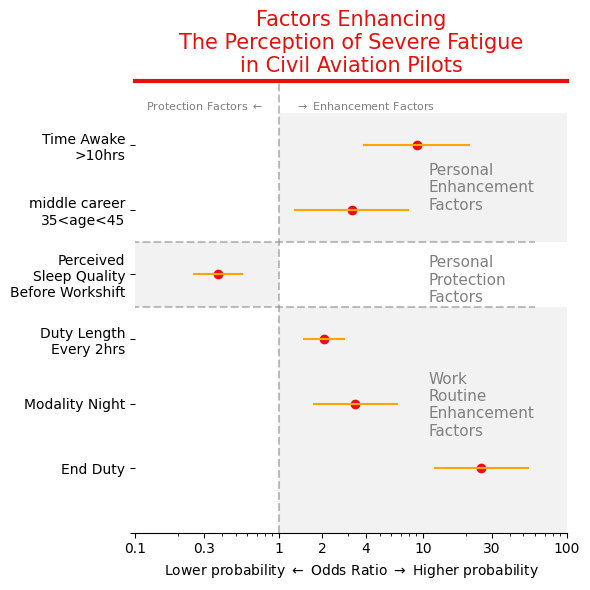

In [24]:
fig, ax = plt.subplots(1,1, figsize = (6,6))

order = ['','duty_moment3end','DMod_fat_2ni','duty_length','Sleep_quality','agemiddle','time_awake']
labs = ['','End Duty','Modality Night', 'Duty Length\nEvery 2hrs', 'Perceived\nSleep Quality\nBefore Workshift','middle career\n35<age<45','Time Awake\n>10hrs']

for i in range(1, len(order)):
    ax.plot( [df_coefs.loc[order[i],'OR_2.5_ci'], df_coefs.loc[order[i],'OR_97.5_ci']], [i,i], color = 'orange')
    ax.scatter(df_coefs.loc[order[i],'OR'], i, color = 'red')

ax.plot([1,1],[0,len(df_coefs)], '--', color = 'gray', alpha = 0.5)
ax.plot([0.001,60], [3.5, 3.5], '--', color = 'gray', alpha = 0.5)
ax.plot([0.001,60], [4.5, 4.5], '--', color = 'gray', alpha = 0.5)

ax.set_xscale('log')
ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('#E3120B')
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(False)

#labs = ['baseline','TPFS_slpem+eve','TPFS_slpNI','duty_momentmiddle','duty_momentstart','DMod_slpni','Sleep_quality','sleep_dur','t_awake']
#labs = order

ax.set_yticks(list(range(len(order))), labels = labs)
ax.set_xticks([0.01, 0.03, 0.1, 0.3, 1, 2, 4, 10, 30, 100], labels = [0.01, 0.03,0.1, 0.3, 1, 2, 4, 10, 30, 100])
ax.set_xlim([0.1, 100])
ax.set_ylim([0, len(order)])

ax.set_xlabel(r"Lower probability $\leftarrow$ Odds Ratio $\rightarrow$ Higher probability")
ax.set_title('Factors Enhancing\nThe Perception of Severe Fatigue\nin Civil Aviation Pilots',
             color = '#E3120B', size = 15)

ax.text(0.12, len(order)-0.45,r'Protection Factors $\leftarrow$',color = 'gray', size = 8 )
ax.text(1.3, len(order)-0.45,   r'$\rightarrow$ Enhancement Factors',color = 'gray', size = 8 )
ax.text(11, 1.5, 'Work\nRoutine\nEnhancement\nFactors', color = 'gray', size = 11)
ax.text(11,3.57, 'Personal\nProtection\nFactors', color = 'gray', size = 11)
ax.text(11,5, 'Personal\nEnhancement\nFactors', color = 'gray', size = 11)

ax.fill([1,100,100,1],[-0.5,-0.5,3.5,3.5], color = 'gray', alpha = 0.1, edgecolor = None)
ax.fill([1,0.001,0.001,1],[4.5,4.5,3.5,3.5], color = 'gray', alpha = 0.1, edgecolor = None)
ax.fill([1,100,100,1],[4.5,4.5,6.5,6.5], color = 'gray', alpha = 0.1 , edgecolor = None)
plt.tight_layout()
plt.show()
fig.savefig('figures/05.coeffs_odds.png')

The figure presents the estimated odds ratios (on a logarithmic scale) from the logistic regression model. The effects can be interpreted as follows

>- **End of the workshift:**
Participants have **25 (12, 53)** times the odds of perceiving severe fatigue compared with the start and middle of the workshift, holding all other covariates constant.
>
>- **Work routines including the Night period (00:00–05:00):**
Participants have **3.4 (1.8, 6.6)** times the odds of perceiving severe fatigue compared with routines that do not include this period, holding all other covariates constant.
>
>- **Every additional 2 hours of work:**
The odds of perceiving severe fatigue increase by a factor of **2.1 (1.5, 2.8)** for each additional 2 hours worked, relative to any baseline, holding all other covariates constant.
>
>- **Higher perceived sleep quality before the workshift:**
Participants have **0.37 (0.25, 0.55)** times the odds—equivalently, 63% (75%, 45%) lower odds—of perceiving severe fatigue compared with the reference sleep-quality level, holding all other covariates constant.
>
>- **Middle-career individuals (ages 35–45):**
Participants in this age range have **3.2 (1.3, 7.9)** times the odds of perceiving severe fatigue compared with younger and older professionals, holding all other covariates constant.
>
>- **Awake for more than 10 hours before the workshift:**
Participants have **9.0 (3.8, 21.0)** times the odds of perceiving severe fatigue compared with those awake ≤10 hours, holding all other covariates constant.

## 7.1. Median Odds Ratio (Heterogeneity among participants)

In order to assess the heterogenity among participants, we will use the $MOR$ (Median Odds Ratio), given by:

$$ \hat{MOR} = exp\left(\sqrt{2\times\sigma_{random}^2}\times\Phi^{-1}(0.80) \right)$$

In [25]:
mor = np.exp( np.sqrt(2*model_LME.ranef_var['Var'])*0.6745)
print('-----------------------------------------')
print(f"MOR = \033[91m{mor.Id:0.3}\033[0m")
print('-----------------------------------------')

-----------------------------------------
MOR = 2.53
-----------------------------------------


>- As we can see above $\hat{MOR} = 2.53$, meaning that the more prone individual has 153% more chances to perceive severe fatigue than the less prone one, considering the covariates baseline.
>
>- This value indicates that there is a considerable variability among individuals under study.

----

# 8. Saving the Model

In [26]:
folder_path = os.path.join('data','models')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    
file_path = os.path.join(folder_path, "05.model.joblib")
try:
    save_model(model_LME, file_path)
    print('-----------------------------------------------')
    print(f"\033[92mSuccess model {file_path} saved!\033[0m")
    print('-----------------------------------------------')
except Exception as e:
    print('-----------------------------------------------')
    print(f"\033[91mAn error occurred:\033[0m {e}")
    print('-----------------------------------------------')

-----------------------------------------------
Success model data\models\05.model.joblib saved!
-----------------------------------------------


---